In [1]:
import open3d as o3d

if __name__ == "__main__":
    dataset = o3d.data.EaglePointCloud()
    pcd = o3d.io.read_point_cloud(dataset.path)
    o3d.visualization.draw(pcd)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/EaglePointCloud.ply
[Open3D INFO] Downloaded to /home/armin/open3d_data/download/EaglePointCloud/EaglePointCloud.ply
[Open3D INFO] Window window_0 created.
[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x138568f0 (threading is enabled)
[Open3D INFO] ICE servers: ["stun:stun.l.google.com:19302", "turn:user:password@34.69.27.100:3478", "turn:user:password@34.69.27.100:3478?transport=tcp"]
EGL(1.5)
OpenGL(4.1)
[Open3D INFO] Set WEBRTC_STUN_SERVER environment variable add a customized WebRTC STUN server.
[Open3D INFO] WebRTC Jupyter handshake mode enabled.


KeyboardInterrupt: 

{'input_ply': 'open3d_data/extract/EaglePointCloud/EaglePointCloud.ply', 'points_shape_xyz': (796825, 3), 'num_points': 796825, 'voxel_size': 1.0, 'volume_shape_zyx': (7, 9, 5), 'value_mode': 'density', 'saved_npy': 'open3d_data/download/EaglePointCloud/EaglePointCloud.npy', 'saved_tif': 'open3d_data/download/EaglePointCloud/EaglePointCloud.tif'}
Point-cloud shape (N, 3): (796825, 3)
Total points: 796825
Volume shape (Z, Y, X): (7, 9, 5)


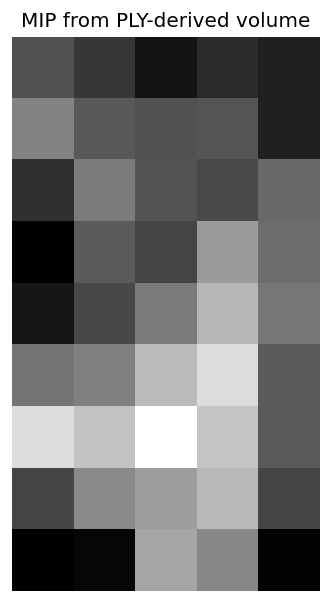

In [5]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import open3d as o3d
import tifffile


def volume_from_ply(
    ply_path: str,
    output_npy: str = "prepared_data/volume_from_ply.npy",
    output_tif: str = "prepared_data/volume_from_ply.tif",
    voxel_size: float = 1.0,
    value_mode: str = "density",
    dtype=np.float32,
) -> tuple[np.ndarray, dict]:
    """Convert a .ply point cloud into a dense 3D volume (Z, Y, X).

    Args:
        ply_path: Input .ply file path.
        output_npy: Path to save volume as .npy.
        output_tif: Path to save volume as .tif.
        voxel_size: Size of voxel in same units as points.
        value_mode: "binary" for occupancy, "density" for hit counts.
    """
    if voxel_size <= 0:
        raise ValueError("voxel_size must be > 0")

    pcd = o3d.io.read_point_cloud(ply_path)
    pts = np.asarray(pcd.points, dtype=np.float64)
    if pts.size == 0:
        raise ValueError(f"No points found in {ply_path}")

    # Shift to origin and quantize into voxel indices.
    mins = pts.min(axis=0)
    shifted = pts - mins
    idx_xyz = np.floor(shifted / float(voxel_size)).astype(np.int64)

    max_xyz = idx_xyz.max(axis=0)
    nx, ny, nz = int(max_xyz[0] + 1), int(max_xyz[1] + 1), int(max_xyz[2] + 1)

    # Volume is stored as (Z, Y, X) for compatibility with the rest of this repo.
    volume = np.zeros((nz, ny, nx), dtype=np.float32)

    # Accumulate occupancy/density.
    xs, ys, zs = idx_xyz[:, 0], idx_xyz[:, 1], idx_xyz[:, 2]
    np.add.at(volume, (zs, ys, xs), 1.0)

    if value_mode == "binary":
        volume = (volume > 0).astype(dtype)
    elif value_mode == "density":
        volume = volume.astype(dtype)
        vmax = float(volume.max())
        if vmax > 0:
            volume /= vmax
    else:
        raise ValueError("value_mode must be either 'binary' or 'density'")

    Path(output_npy).parent.mkdir(parents=True, exist_ok=True)
    Path(output_tif).parent.mkdir(parents=True, exist_ok=True)
    np.save(output_npy, volume)
    tifffile.imwrite(output_tif, volume.astype(np.float32))

    info = {
        "input_ply": ply_path,
        "points_shape_xyz": tuple(int(v) for v in pts.shape),
        "num_points": int(pts.shape[0]),
        "voxel_size": float(voxel_size),
        "volume_shape_zyx": tuple(int(v) for v in volume.shape),
        "value_mode": value_mode,
        "saved_npy": output_npy,
        "saved_tif": output_tif,
    }
    return volume, info


def mip_z(volume_zyx: np.ndarray) -> np.ndarray:
    """Max projection along Z axis -> (Y, X)."""
    return volume_zyx.max(axis=0)


def show_mip_with_open3d(mip_yx: np.ndarray, title: str = "MIP (Z-axis)"):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6), dpi=120)
    plt.imshow(mip_yx, cmap="gray", origin="lower")
    plt.title(title)
    plt.axis("off")
    plt.show()


# Example: ONLY .ply input
ply_path = "open3d_data/extract/EaglePointCloud/EaglePointCloud.ply"  # change to your PLY path

volume, info = volume_from_ply(
    ply_path=ply_path,
    output_npy="open3d_data/download/EaglePointCloud/EaglePointCloud.npy",
    output_tif="open3d_data/download/EaglePointCloud/EaglePointCloud.tif",
    voxel_size=1.0,
    value_mode="density",  # or "binary"
  )

print(info)
print("Point-cloud shape (N, 3):", info["points_shape_xyz"])
print("Total points:", info["num_points"])
print("Volume shape (Z, Y, X):", info["volume_shape_zyx"])
show_mip_with_open3d(mip_z(volume), title="MIP from PLY-derived volume")

In [1]:
import torch
model_dir = "checkpoints/gmf_refined_best.pt"
load = torch.load(model_dir, map_location="cpu", weights_only=True)


In [3]:
load.keys()

odict_keys(['means', 'log_scales', 'quaternions', 'log_amplitudes'])